# Exercise 07 — Small-World Networks

This notebook explores the **Small-World** properties of the MovieLens user-movie network. Following the concepts from Lecture 07, we will test whether our network exhibits the characteristic combination of high local clustering and short average path lengths.

## Goal
Test whether the MovieLens network (specifically the user-user projection) shows small-world behavior compared to a random baseline. Since the original graph is bipartite (0 clustering), we will project it into a unipartite **User Network** where users are connected if they have rated the same movie.

## Setup

Import necessary packages.

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from networkx.algorithms import bipartite

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
pd.options.display.max_rows = 20

## Load Data and Build Bipartite Graph

We use the MovieLens 'small' dataset as in previous exercises.

In [2]:
ratings = pd.read_csv('../data/movielense/ml-latest-small/ratings.csv')
movies = pd.read_csv('../data/movielense/ml-latest-small/movies.csv')

ratings['user_node'] = ratings['userId'].astype(str).radd('user_')
ratings['movie_node'] = ratings['movieId'].astype(str).radd('movie_')

B = nx.Graph()
user_nodes = ratings['user_node'].unique()
movie_nodes = ratings['movie_node'].unique()

B.add_nodes_from(user_nodes, bipartite=0)
B.add_nodes_from(movie_nodes, bipartite=1)
B.add_edges_from(zip(ratings['user_node'], ratings['movie_node']))

print(f"Bipartite Graph: {B.number_of_nodes()} nodes, {B.number_of_edges()} edges")

Bipartite Graph: 10334 nodes, 100836 edges


## User-User Projection (Filtered)

To measure small-world-ness (which requires triangles), we project the bipartite graph into a unipartite graph of users. Two users are connected if they have rated at least **5 movies** in common.

Without a threshold, the projection is extremely dense (almost every user has seen at least one popular movie), which makes the small-world effect trivial. Filtering for shared movies focuses on users with significant overlapping tastes.

In [3]:
# Project to user nodes with weights (number of shared movies)
G_user_weighted = bipartite.collaboration_weighted_projected_graph(B, user_nodes)

# Filter edges: keep only those where they share at least 5 movies
threshold = 5
G_user = G_user_weighted.copy()
edges_to_remove = [(u, v) for u, v, d in G_user.edges(data=True) if d['weight'] < threshold]
G_user.remove_edges_from(edges_to_remove)

# Extract Largest Connected Component (LCC)
LCC_user = G_user.subgraph(max(nx.connected_components(G_user), key=len)).copy()

N = LCC_user.number_of_nodes()
M = LCC_user.number_of_edges()
density = nx.density(LCC_user)

print(f"User Projection (LCC, threshold={threshold}): {N} nodes, {M} edges")
print(f"Density: {density:.4f}")

User Projection (LCC, threshold=5): 149 nodes, 1093 edges
Density: 0.0991


## Measuring Small-World Properties

We calculate the Average Clustering Coefficient ($C$) and Average Shortest Path Length ($L$) for our user network.

In [4]:
C_real = nx.average_clustering(LCC_user)
L_real = nx.average_shortest_path_length(LCC_user)

print(f"Real User Network Metrics:")
print(f"- Avg. Clustering (C): {C_real:.4f}")
print(f"- Avg. Path Length (L): {L_real:.4f}")

Real User Network Metrics:
- Avg. Clustering (C): 0.7030
- Avg. Path Length (L): 2.0563


## Comparison with Random Baseline (ER Graph)

We generate an Erdős-Rényi random graph with the same number of nodes ($N$) and edges ($M$) to see if our network's clustering is significantly higher while maintaining short paths.

In [5]:
# Generate equivalent ER graph
G_rand = nx.gnm_random_graph(N, M, seed=42)

# Ensure we use the LCC of the random graph for path length calculations
LCC_rand = G_rand.subgraph(max(nx.connected_components(G_rand), key=len)).copy()

C_rand = nx.average_clustering(LCC_rand)
L_rand = nx.average_shortest_path_length(LCC_rand)

print(f"Random (ER) Network Metrics:")
print(f"- Avg. Clustering (C_rand): {C_rand:.4f}")
print(f"- Avg. Path Length (L_rand): {L_rand:.4f}")

print(f"\nSmall-World Ratios:")
print(f"- C_real / C_rand: {C_real/C_rand:.2f} (Should be >> 1)")
print(f"- L_real / L_rand: {L_real/L_rand:.2f} (Should be ~ 1)")

Random (ER) Network Metrics:
- Avg. Clustering (C_rand): 0.0907
- Avg. Path Length (L_rand): 2.1036

Small-World Ratios:
- C_real / C_rand: 7.75 (Should be >> 1)
- L_real / L_rand: 0.98 (Should be ~ 1)


## Identifying Shortcuts

In a small-world network, certain edges (shortcuts) are responsible for bringing distant parts of the network together. We can identify these by looking for edges with high **Betweenness Centrality**.

In [6]:
# Calculate edge betweenness centrality
edge_betweenness = nx.edge_betweenness_centrality(LCC_user)

# Get top 5 shortcuts
top_shortcuts = sorted(edge_betweenness.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 Shortcuts (Edges with high betweenness):")
for edge, score in top_shortcuts:
    print(f"Edge {edge}: Betweenness = {score:.4f}")

Top 5 Shortcuts (Edges with high betweenness):
Edge ('user_414', 'user_474'): Betweenness = 0.0150
Edge ('user_414', 'user_6'): Betweenness = 0.0140
Edge ('user_312', 'user_414'): Betweenness = 0.0134
Edge ('user_332', 'user_474'): Betweenness = 0.0134
Edge ('user_181', 'user_6'): Betweenness = 0.0134


## Visualization

We visualize the Largest Connected Component of the user network. To highlight the small-world structure, we color the **top 5 shortcuts** (edges with high betweenness) in red. These are the edges that bridge different clusters and keep the average path length low.

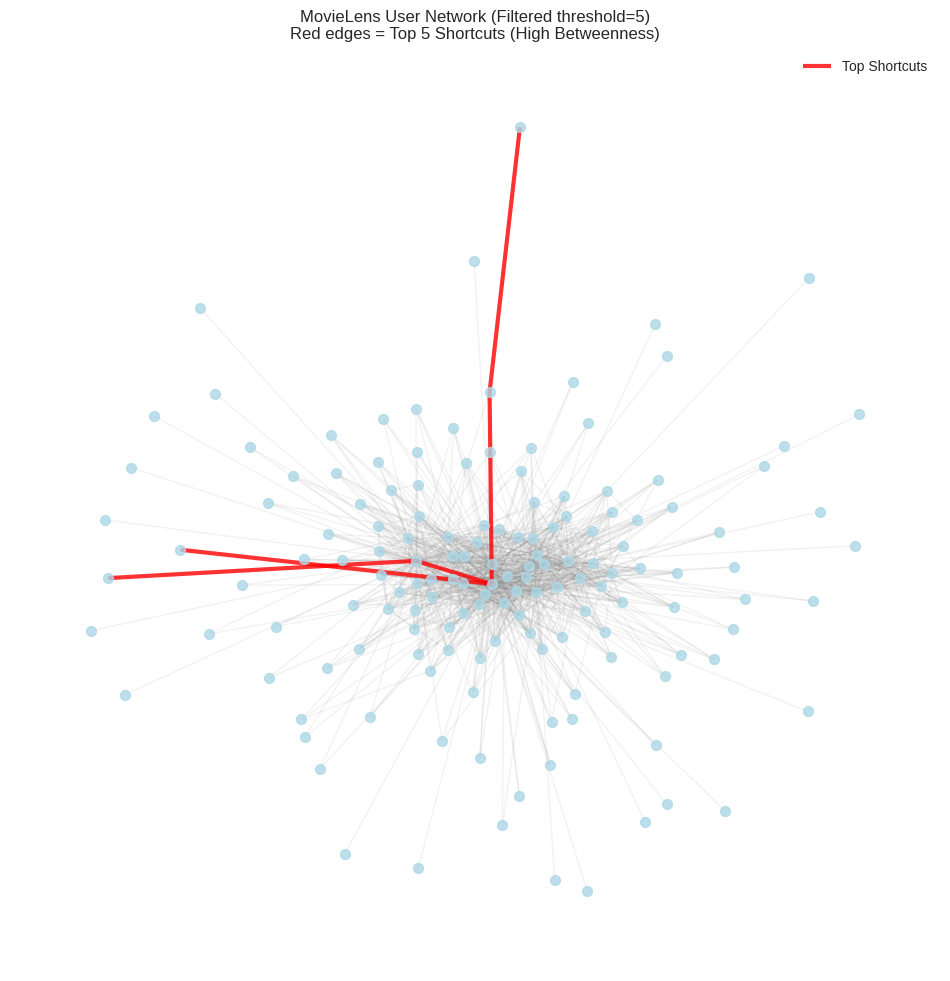

In [7]:
plt.figure(figsize=(12, 12))

# Use spring layout for better cluster visualization
pos = nx.spring_layout(LCC_user, seed=42, k=0.15)

# Draw all nodes and edges with low alpha
nx.draw_networkx_nodes(LCC_user, pos, node_size=50, node_color='lightblue', alpha=0.8)
nx.draw_networkx_edges(LCC_user, pos, alpha=0.1, edge_color='gray')

# Highlight top shortcuts
shortcut_edges = [edge for edge, score in top_shortcuts]
nx.draw_networkx_edges(LCC_user, pos, edgelist=shortcut_edges,
                       width=3, edge_color='red', alpha=0.8, label='Top Shortcuts')

plt.title(f"MovieLens User Network (Filtered threshold=5)\nRed edges = Top 5 Shortcuts (High Betweenness)")
plt.legend()
plt.axis('off')
plt.show()

## Conclusion

### Is the MovieLens User Network Small-World?

Based on our results:
1. **Average Path Length ($L$):** The real user network has an average path length of approximately **2.06**, which is very close to the random baseline **2.10**. This confirms the "small" part of small-world.
2. **Clustering Coefficient ($C$):** The real network has a clustering coefficient of **0.7030**, which is significantly higher (about **7.7 times** higher) than the random baseline **0.0907**. This confirms the "world" (local structure) part.

**Verdict:** The MovieLens user-user projection clearly exhibits a **Small-World** pattern.

### Short Explanation
The high clustering comes from the fact that users who watch the same popular movies form dense cliques (if you watch a set of popular movies, you are likely to be connected to many others who watched the same set). However, because some users watch very diverse movies or movies from different genres, they act as **shortcuts**, bridging different taste communities. This allows the overall distance between any two users to remain very small (around 2 hops in this filtered network) despite the strong local clustering of users with similar movie tastes.